Transformacion de los datos mediant escalado y normalizacion
Escalamiento Min Max

Estandarizacion Z-score
Concatenar los DF para comparacion
         Peso_kg        Precio  Peso_MinMax  Precio_MinMax  Peso_Standard  \
0    1599.342831  51622.651388     0.613116       0.472492       0.616529   
1    1472.347140  38271.243839     0.488193       0.327541      -0.059559   
2    1629.537708  28546.213871     0.642818       0.221960       0.777277   
3    1804.605971   9757.834524     0.815028       0.017982       1.709289   
4    1453.169325  11525.884294     0.469329       0.037177      -0.161656   
..           ...           ...          ...            ...            ...   
145  1656.364574  19377.982626     0.669206       0.122424       0.920095   
146  1252.609858  18166.732292     0.272044       0.109274      -1.229375   
147  1235.908677  27134.448658     0.255615       0.206633      -1.318287   
148  1604.388313  28162.290721     0.618079       0.217792       0.643389   
149  1559.3

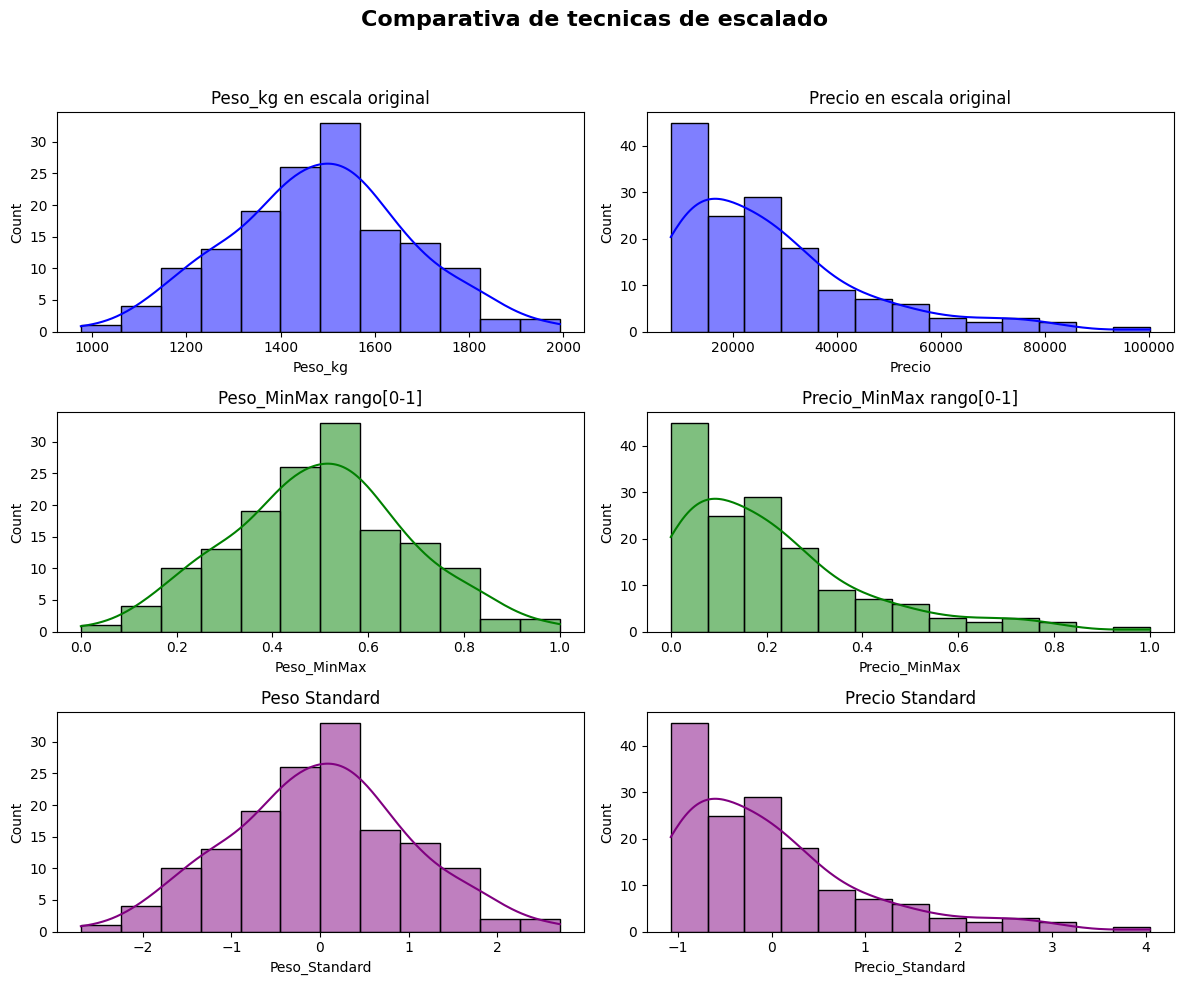

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler,StandardScaler

print("Transformacion de los datos mediant escalado y normalizacion")

#crear set de datos, con problema de magnitud
np.random.seed(42)
datos_autos={
#                                       desviacion
    'Peso_kg':np.random.normal(loc=1500,scale=200,size=150),
    'Precio':np.random.exponential(scale=20000,size=150)+8000,
    
}

df_autos=pd.DataFrame(datos_autos)
print("Escalamiento Min Max")
#crear el escalador
min_max_escalador=MinMaxScaler()
df_autos_minmax=pd.DataFrame(
    
    min_max_escalador.fit_transform(df_autos),#encuentra el minimo y maximo de la columna de peso y precio y los transforma a un rango de 0 a 1
    columns=['Peso_MinMax','Precio_MinMax']
    
)
#print(df_autos_minmax)
print()
print("Estandarizacion Z-score")
standard_escalador=StandardScaler()
df_autos_standard=pd.DataFrame(
    
    standard_escalador.fit_transform(df_autos),#encuentra la media y desviacion estandar de la columna de peso y precio y los transforma a un rango de -3 a 3
    columns=['Peso_Standard','Precio_Standard']
    
)

#print(df_autos_standard)
print("Concatenar los DF para comparacion")
df_final=pd.concat([df_autos,df_autos_minmax,df_autos_standard],axis=1)#unir todos los dtframe por columnas
print(df_final)



print()
print("Comparacion visual con Histograma")
fig, axs=plt.subplots(3,2,figsize=(12,10))
fig.suptitle('Comparativa de tecnicas de escalado',fontsize=16,fontweight='bold')

#Fila 1 datos con problemas de magnitudes
sns.histplot(data=df_final['Peso_kg'],ax=axs[0,0],color='blue',kde=True)
axs[0,0].set_title('Peso_kg en escala original')
sns.histplot(data=df_final['Precio'],ax=axs[0,1],color='blue',kde=True)
axs[0,1].set_title('Precio en escala original')

# Fila 2 Escalamiento Min Max
sns.histplot(data=df_final['Peso_MinMax'],ax=axs[1,0],color='green',kde=True)
axs[1,0].set_title('Peso_MinMax rango[0-1]')
sns.histplot(data=df_final['Precio_MinMax'],ax=axs[1,1],color='green',kde=True)
axs[1,1].set_title('Precio_MinMax rango[0-1]')


#Fila 3 Z-score
sns.histplot(data=df_final['Peso_Standard'],ax=axs[2,0],color='purple',kde=True)
axs[2,0].set_title('Peso Standard')
sns.histplot(data=df_final['Precio_Standard'],ax=axs[2,1],color='purple',kde=True)
axs[2,1].set_title('Precio Standard') 

# ajusta los espacios entre los graficos y el titulo general
plt.tight_layout(rect=[0,0,1,0.95])# permite que esos graficos ocupen toda la figura menos el 5%
plt.show()
